In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import math

# Análise Exploratória dos Resultados de Segmentação dos Óstios
Este notebook realiza uma análise exploratória dos resultados da segmentação dos óstios a partir do pipeline. São apresentados gráficos e estatísticas para avaliar a qualidade das segmentações.

## Carregamento dos Dados
Os dados de saída do pipeline são carregados a partir do arquivo CSV gerado, contendo as informações de status e coordenadas dos óstios para cada imagem.

In [2]:
df = pd.read_csv("../output/ostios_train_summary.csv")
df.head()

,IMG_ID,dice_artery,artery_voxels,both_correct,both_tolerable,left_intersects,right_intersects,left_dist_mm,right_dist_mm,ostia_left,ostia_right,error,status
0,516,NaN,NaN,False,False,False,False,2.335297,9.115018,"(137, 116, 196)","(159, 67, 176)",NaN,nenhum correto
1,832,0.748620,38821.0,False,True,False,False,2.812500,0.862777,"(91, 156, 194)","(106, 127, 227)",NaN,ambos toleráveis
2,575,NaN,NaN,False,False,False,False,53.799362,28.370455,"(37, 163, 228)","(92, 133, 232)",NaN,nenhum correto
3,587,0.554134,73679.0,False,True,False,False,0.656250,1.650047,"(107, 161, 201)","(120, 131, 237)",NaN,ambos toleráveis
4,633,0.690493,37902.0,False,True,True,False,0.000000,0.687500,"(96, 154, 177)","(111, 118, 209)",NaN,ambos toleráveis


## Distribuição dos Status de Segmentação
Visualização da quantidade de imagens para cada status de segmentação dos óstios.

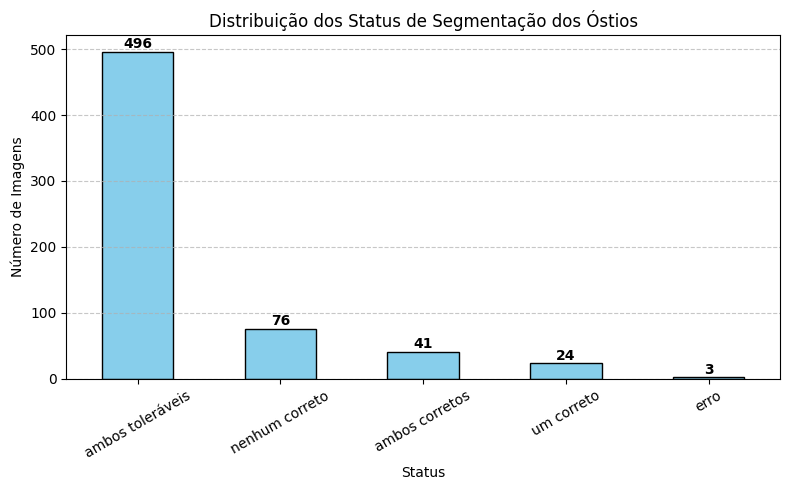

In [3]:

status_counts = df['status'].value_counts()

plt.figure(figsize=(8, 5))
ax = status_counts.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Distribuição dos Status de Segmentação dos Óstios')
plt.xlabel('Status')
plt.ylabel('Número de Imagens')
plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

for i, v in enumerate(status_counts.values):
    ax.text(i, v + 0.5, str(v), ha='center', va='bottom', fontweight='bold')

plt.show()

## Acertos e Erros na Segmentação
Aqui calculamos e visualizamos a proporção de acertos (ambos toleráveis ou ambos corretos) e erros nas segmentações dos óstios.

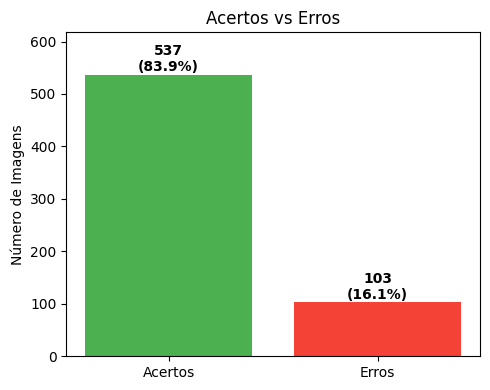

In [4]:
total = len(df)
successful_count = df['status'].isin(['ambos toleráveis', 'ambos corretos']).sum()
error_count = total - successful_count

success_percentage = 100 * successful_count / total if total > 0 else 0
error_percentage = 100 * error_count / total if total > 0 else 0

# Gráfico de barras
plt.figure(figsize=(5, 4))
plt.bar(['Acertos', 'Erros'], [successful_count, error_count], color=['#4CAF50', '#F44336'])
plt.ylabel('Número de Imagens')
plt.title('Acertos vs Erros')
for i, v in enumerate([successful_count, error_count]):
    plt.text(i, v + 0.5, f'{v}\n({[success_percentage, error_percentage][i]:.1f}%)', ha='center', va='bottom', fontweight='bold')
plt.ylim(0, max(successful_count, error_count) * 1.15)
plt.tight_layout()
plt.show()

## Análise das Distâncias entre Óstios por Status
A seguir, analisamos a distância euclidiana entre os óstios segmentados, separando por status, para investigar possíveis diferenças entre os grupos.

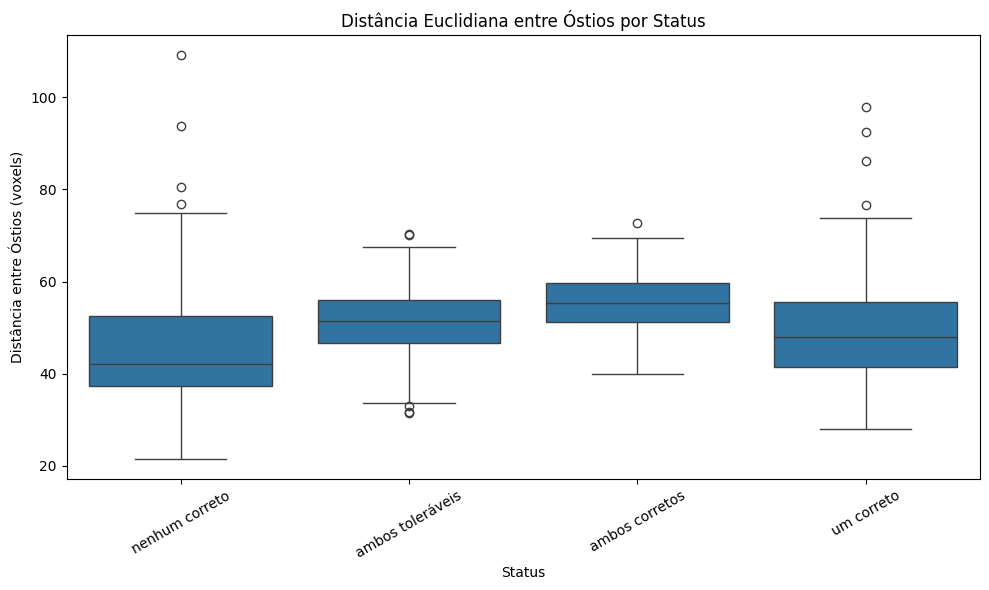

In [5]:
def safe_eval_tuple(x):
    try:
        if isinstance(x, float) and math.isnan(x):
            return np.array([np.nan, np.nan, np.nan])
        return np.array(eval(str(x), {"nan": np.nan}), dtype=float)
    except Exception:
        return np.array([np.nan, np.nan, np.nan])

ostia_left_arr = df['ostia_left'].apply(safe_eval_tuple)
ostia_right_arr = df['ostia_right'].apply(safe_eval_tuple)
df['dist_ostios'] = [np.linalg.norm(l - r) for l, r in zip(ostia_left_arr, ostia_right_arr)]

df_no_error = df[(df['status'] != 'erro') & (~df['dist_ostios'].isna()) & (df['dist_ostios'] < 1e6)]

plt.figure(figsize=(10, 6))
sns.boxplot(x='status', y='dist_ostios', data=df_no_error)
plt.title('Distância Euclidiana entre Óstios por Status')
plt.xlabel('Status')
plt.ylabel('Distância entre Óstios (voxels)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Média das Distâncias entre Óstios por Status
Tabela com a média das distâncias entre os óstios para cada status de segmentação.

In [6]:
df_grouped = df_no_error.groupby('status', as_index=False)['dist_ostios'].mean()
df_grouped

,status,dist_ostios
0,ambos corretos,56.184963
1,ambos toleráveis,51.343903
2,nenhum correto,46.330627
3,um correto,52.584581


## Dice Score

In [7]:
# Dice score médio (ignora NaN)
if "dice_artery" in df.columns:
    df = df[df["dice_artery"] != 0]

    dice_values = df["dice_artery"].dropna()
    dice_mean = float(dice_values.mean()) if not dice_values.empty else 0.0
    print(f"Dice score médio: {dice_mean:.6f}")
else:
    print("Coluna 'dice_artery' não encontrada no CSV.")

Dice score médio: 0.627825
